# Roman Strong Lens Data Challenge — Rung 0

En esta etapa del challenge vamos a entrenar un **modelo de regresión** que prediga el **radio de Einstein** ($\theta_E$) de un sistema de lente gravitacional fuerte.

El dataset contiene:

- ~11,000 lentes simulados
- 3 bandas por lente: F106, F129, F158
- Parámetros físicos reales del sistema (masa, redshifts, dispersión de velocidad, etc.)
- El valor verdadero de $\theta_E$ (nuestro label)

Objetivo:

Input: Imagen multibanda (91 × 91 × 3)  
Output: $\theta_E$ en arcsec  

Esta es una tarea de **regresión supervisada**.

## Explorando la estructura del dataset HDF5

El archivo `.h5` está organizado jerárquicamente:

root  
└── images  
    ├── strong_lens_00000000  
    ├── strong_lens_00000001  
    └── ...  

Cada lente contiene:

- Atributos físicos (incluye `theta_e`)
- Tres exposiciones (una por filtro)

Vamos a inspeccionar la estructura.

In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

# Cambia esto a tu ruta local si hace falta
h5_filepath = "roman_data_challenge_rung_0_v_1_0.h5"
assert os.path.exists(h5_filepath), f"No encuentro el archivo: {h5_filepath}"

In [2]:
f = h5py.File(h5_filepath, "r")

print("ROOT KEYS:", list(f.keys()))
print("\n--- ROOT ATTRS ---")
for k, v in f.attrs.items():
    print(f"{k}: {v}")

ROOT KEYS: ['images']

--- ROOT ATTRS ---
author: ['bwedig@galileo.physics.wustl.edu' 'username@host for calculation']
created: 2025_10_31-11_26_28_AM
dataset_version: 1.0
galsim_version: ['2.5.1' 'GalSim version']
lenstronomy_version: ['1.13.2' 'lenstronomy version']
mejiro_version: ['2.0.0' 'mejiro version']
slsim_version: ['0.1.0' 'SLSim version']
stpsf_version: ['2.1.0' 'STPSF version']


In [3]:
images_group = f["images"]
print("N lenses:", len(images_group.keys()))
pprint(list(images_group.keys())[:10])

N lenses: 11160
['strong_lens_00000000',
 'strong_lens_00000001',
 'strong_lens_00000002',
 'strong_lens_00000003',
 'strong_lens_00000004',
 'strong_lens_00000005',
 'strong_lens_00000006',
 'strong_lens_00000007',
 'strong_lens_00000008',
 'strong_lens_00000009']


In [4]:
#  CELDA 4 (Código)
lens = images_group["strong_lens_00000000"]

print("--- LENS ATTRS ---")
for k, v in lens.attrs.items():
    print(f"{k}: {v}")

print("\nData keys:", list(lens.keys()))

--- LENS ATTRS ---
LOS_normalization: ['1.0' 'See pyHalo documentation']
concentration_model_fieldhalos: ['LUDLOW2016' 'See pyHalo documentation']
concentration_model_subhalos: ['LUDLOW2016' 'See pyHalo documentation']
detector: ['1' 'Detector']
detector_position_x: ['409' 'Detector X position']
detector_position_y: ['2044' 'Detector Y position']
log_mhigh: ['12' 'See pyHalo documentation']
log_mlow: ['6' 'See pyHalo documentation']
main_halo_mass: ['4959152151728.72' 'Lens galaxy main halo mass [M_sun]']
mu: ['3.0997306280034085' 'Flux-weighted magnification of source']
r_tidal: ['0.5' 'See pyHalo documentation']
shmf_log_slope: ['-1.9' 'See pyHalo documentation']
sigma_sub: ['0.055' 'See pyHalo documentation']
sigma_v: ['206.81130327367515' 'Lens galaxy velocity dispersion [km/s]']
substructure: ['True' 'Is substructure present in this lens?']
theta_e: ['0.6663028384837842' 'Einstein radius [arcsec]']
uid: ['00000000' 'Unique identifier for system assigned by mejiro']
z_lens: ['1.037

In [5]:
#celda 5
uid = lens.attrs["uid"][0]
exp_key = f"exposure_{uid}_F106"
exp = lens[exp_key]

print("--- EXPOSURE ATTRS ---")
for k, v in exp.attrs.items():
    print(f"{k}: {v}")

print("\nExposure shape:", exp[:].shape)


--- EXPOSURE ATTRS ---
exposure_time: ['642' 'Exposure time [seconds]']
filter: ['F106' 'Filter']
fov: ['10.01' 'Field of view [arcsec]']
lens_magnitude: ['22.194308043660254' 'Lens galaxy magnitude']
lensed_source_magnitude: ['23.293477562952464' 'Lensed source galaxy magnitude']
pixel_scale: ['0.11' 'Pixel scale [arcsec/pixel]']
snr: ['20.435625947519355' 'Signal-to-noise ratio']
source_magnitude: ['24.521787449268203' 'Unlensed source galaxy magnitude']
units: ['Counts/sec' 'Units of pixel values']

Exposure shape: (91, 91)


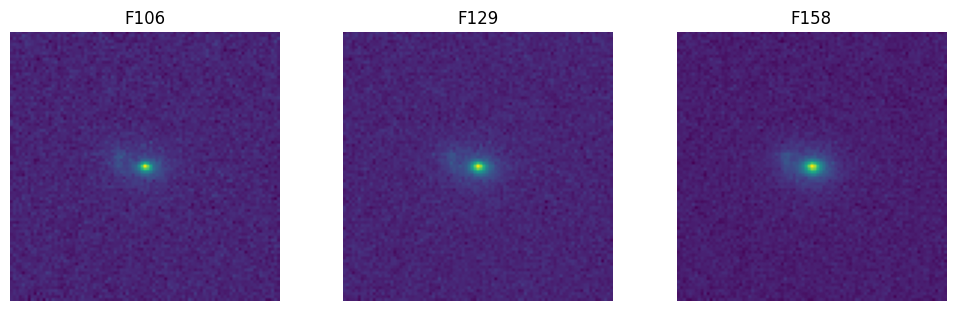

In [6]:
#celda 6

filters = ["F106", "F129", "F158"]
fig, ax = plt.subplots(1, 3, figsize=(10, 3), constrained_layout=True)

for i, flt in enumerate(filters):
    dset = lens[f"exposure_{uid}_{flt}"][:]
    ax[i].imshow(np.log10(dset + 1e-12), origin="lower")
    ax[i].set_title(flt)
    ax[i].axis("off")

plt.show()

In [7]:
#celda 7
def normalize01(x):
    x = x.astype(np.float32)
    mn, mx = np.min(x), np.max(x)
    if mx - mn < 1e-12:
        return np.zeros_like(x, dtype=np.float32)
    return (x - mn) / (mx - mn)

def load_rgb_and_label(lens_group):
    uid = lens_group.attrs["uid"][0]
    y = float(lens_group.attrs["theta_e"][0])  # label

    r = normalize01(lens_group[f"exposure_{uid}_F158"][:])
    g = normalize01(lens_group[f"exposure_{uid}_F129"][:])
    b = normalize01(lens_group[f"exposure_{uid}_F106"][:])

    x = np.stack([r, g, b], axis=-1)  # (91,91,3)
    return x, y

# Para modo escuela: empieza con subset
N_MAX = 2000  # sube luego a len(images_group) cuando quieras
keys = list(images_group.keys())[:N_MAX]

X = np.zeros((len(keys), 91, 91, 3), dtype=np.float32)
y = np.zeros((len(keys),), dtype=np.float32)

for i, k in enumerate(keys):
    x_i, y_i = load_rgb_and_label(images_group[k])
    X[i] = x_i
    y[i] = y_i

print("X:", X.shape, "y:", y.shape, "theta_e range:", (y.min(), y.max()))

X: (2000, 91, 91, 3) y: (2000,) theta_e range: (0.14800256, 3.7550883)


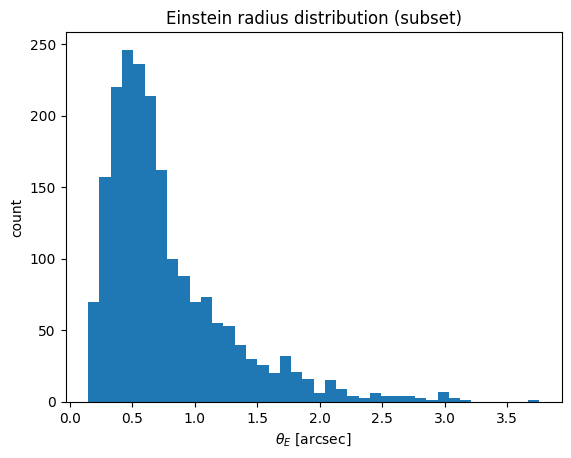

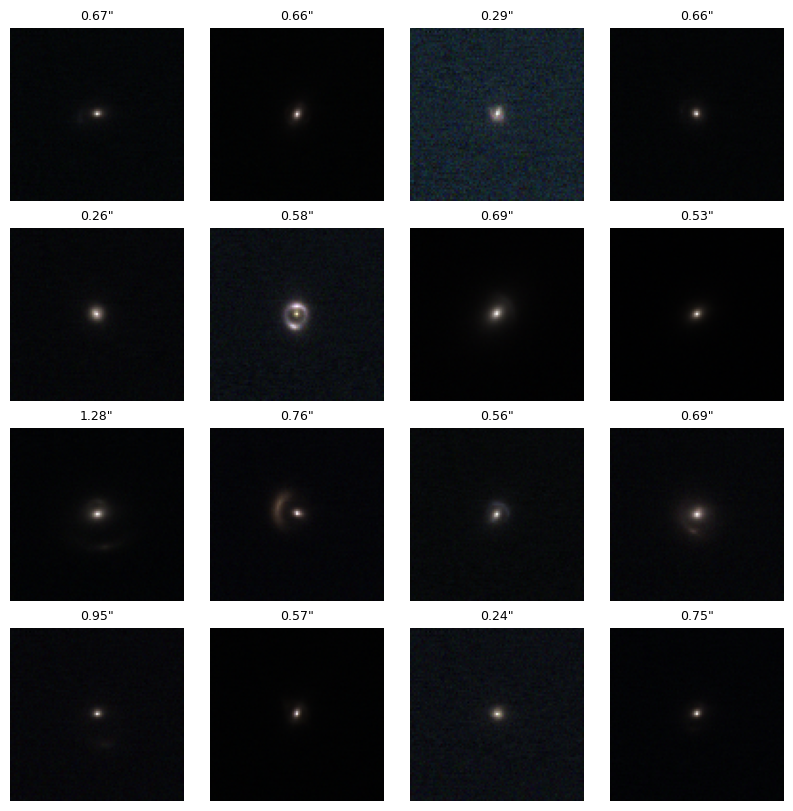

In [8]:
#celda 8
plt.hist(y, bins=40)
plt.xlabel(r"$\theta_E$ [arcsec]")
plt.ylabel("count")
plt.title("Einstein radius distribution (subset)")
plt.show()

# grid de ejemplos
grid = 4
fig, ax = plt.subplots(grid, grid, figsize=(8, 8), constrained_layout=True)
for i in range(grid*grid):
    ax[i//grid, i%grid].imshow(X[i])
    ax[i//grid, i%grid].set_title(f"{y[i]:.2f}\"", fontsize=9)
    ax[i//grid, i%grid].axis("off")
plt.show()

In [9]:
#celda 9
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_flat = X.reshape(len(X), -1)

X_train, X_tmp, y_train, y_tmp = train_test_split(X_flat, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42)

model = make_pipeline(StandardScaler(with_mean=True), Ridge(alpha=10.0))
model.fit(X_train, y_train)

def eval_reg(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")

y_pred_val = model.predict(X_val)
y_pred_test = model.predict(X_test)

eval_reg("VAL", y_val, y_pred_val)
eval_reg("TEST", y_test, y_pred_test)

VAL: MAE=0.3801, RMSE=0.5385, R2=-0.1781
TEST: MAE=0.4442, RMSE=0.6069, R2=-0.4144


/home/kingsman/.local/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:253: LinAlgWarning: Ill-conditioned matrix (rcond=1.60247e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)


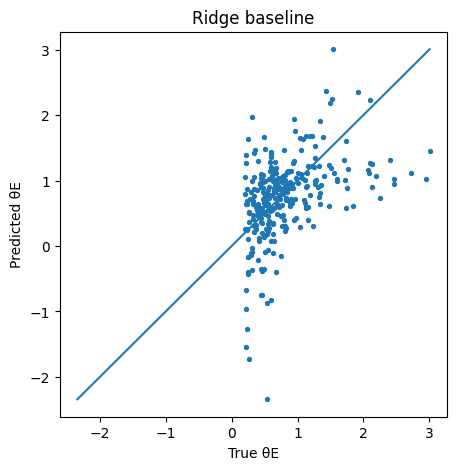

In [10]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_test, s=8)
mn, mx = min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())
plt.plot([mn, mx], [mn, mx])
plt.xlabel("True θE")
plt.ylabel("Predicted θE")
plt.title("Ridge baseline")
plt.show()

---
Con pytorch

In [11]:
#celda 11
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [12]:
# Regresamos a X (N,91,91,3) -> PyTorch quiere (N,3,91,91)
Xt = torch.from_numpy(X).permute(0,3,1,2)
yt = torch.from_numpy(y).unsqueeze(1)

# índices según split anterior
# (reconstruimos usando tamaños; para algo más limpio luego guardamos indices explícitos)
n_train = len(X_train)
n_val = len(X_val)
n_test = len(X_test)

# ojo: como hicimos split sobre X_flat, aquí reconstruimos por orden;
# para notebook escuela funciona si mantienes consistencia. Alternativa robusta: split por índices.
# Para hacerlo robusto:
idx = np.arange(len(X))
idx_train, idx_tmp, _, _ = train_test_split(idx, y, test_size=0.3, random_state=42)
idx_val, idx_test, _, _ = train_test_split(idx_tmp, y[idx_tmp], test_size=0.5, random_state=42)

train_ds = TensorDataset(Xt[idx_train].float(), yt[idx_train].float())
val_ds   = TensorDataset(Xt[idx_val].float(),   yt[idx_val].float())
test_ds  = TensorDataset(Xt[idx_test].float(),  yt[idx_test].float())

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False)

len(train_ds), len(val_ds), len(test_ds)

(1400, 300, 300)

In [13]:
class SmallCNNRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # 45
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # 22
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),         # 1x1
            nn.Flatten(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model_cnn = SmallCNNRegressor().to(device)
loss_fn = nn.MSELoss()
opt = torch.optim.Adam(model_cnn.parameters(), lr=1e-3)

In [16]:
def run_epoch(loader, train=True):
    model_cnn.train(train)
    total_loss = 0.0
    n = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        if train:
            opt.zero_grad()
        pred = model_cnn(xb)
        loss = loss_fn(pred, yb)
        if train:
            loss.backward()
            opt.step()
        total_loss += loss.item() * len(xb)
        n += len(xb)
    return total_loss / n

for epoch in range(1, 550):
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader, train=False)
    #print(f"epoch {epoch:02d} | train {tr:.5f} | val {va:.5f}")

print(f"epoch {epoch:02d} | train {tr:.5f} | val {va:.5f}")

epoch 549 | train 0.07271 | val 0.12515


In [21]:
import matplotx
plt.style.use(matplotx.styles.dracula)

CNN TEST: MAE=0.2318, RMSE=0.3296, R2=0.5829


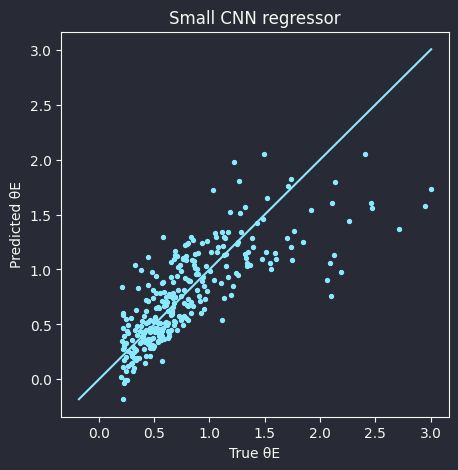

In [22]:
model_cnn.eval()
preds, trues = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        p = model_cnn(xb).cpu().numpy().ravel()
        preds.append(p)
        trues.append(yb.numpy().ravel())

y_pred = np.concatenate(preds)
y_true = np.concatenate(trues)

eval_reg("CNN TEST", y_true, y_pred)

plt.figure(figsize=(5,5))
plt.scatter(y_true, y_pred, s=8)
mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx])
plt.xlabel("True θE")
plt.ylabel("Predicted θE")
plt.title("Small CNN regressor")
plt.show()


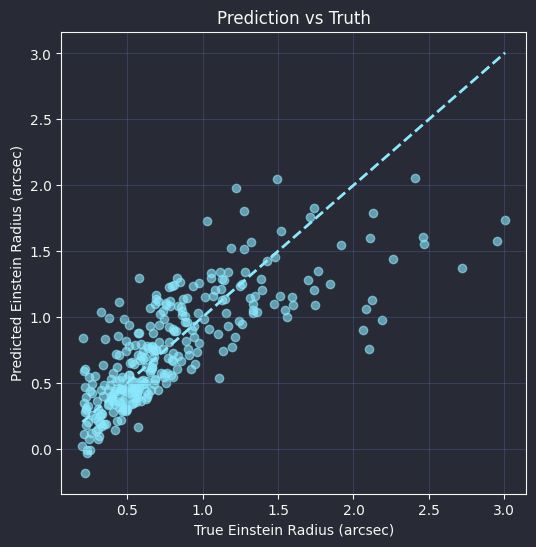

In [25]:
# ==========================================================
# Global Prediction vs Truth
# # ==========================================================

# model_cnn.eval()
# with torch.no_grad():
#     y_pred = model(torch.tensor(X_val, dtype=torch.float32).to(device))
#     y_pred = y_pred.cpu().numpy().flatten()

# y_true = y_val.flatten()

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.6)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         '--', linewidth=2)

plt.xlabel("True Einstein Radius (arcsec)")
plt.ylabel("Predicted Einstein Radius (arcsec)")
plt.title("Prediction vs Truth")
plt.grid(alpha=0.3)
plt.show()

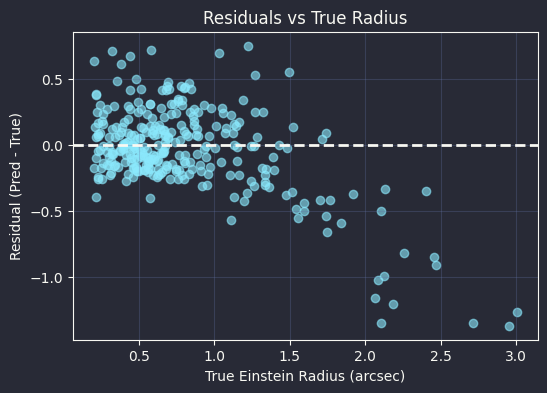

In [27]:
# ==========================================================
# Residual Plot
# ==========================================================

residuals = y_pred - y_true

plt.figure(figsize=(6,4))
plt.scatter(y_true, residuals, alpha=0.6)
plt.axhline(0, linestyle='--', linewidth=2)
plt.xlabel("True Einstein Radius (arcsec)")
plt.ylabel("Residual (Pred - True)")
plt.title("Residuals vs True Radius")
plt.grid(alpha=0.3)
plt.show()

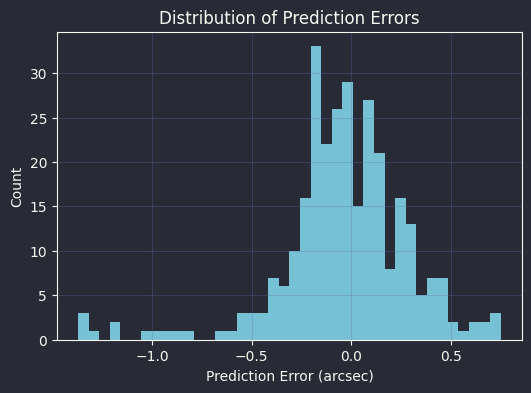

In [28]:
# ==========================================================
# Error Distribution
# ==========================================================

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=40, alpha=0.8)
plt.xlabel("Prediction Error (arcsec)")
plt.ylabel("Count")
plt.title("Distribution of Prediction Errors")
plt.grid(alpha=0.3)
plt.show()

In [30]:
# ==========================================================
# Metrics
# ==========================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.4f} arcsec")
print(f"MAE : {mae:.4f} arcsec")
print(f"R²  : {r2:.4f}")

RMSE: 0.3296 arcsec
MAE : 0.2318 arcsec
R²  : 0.5829


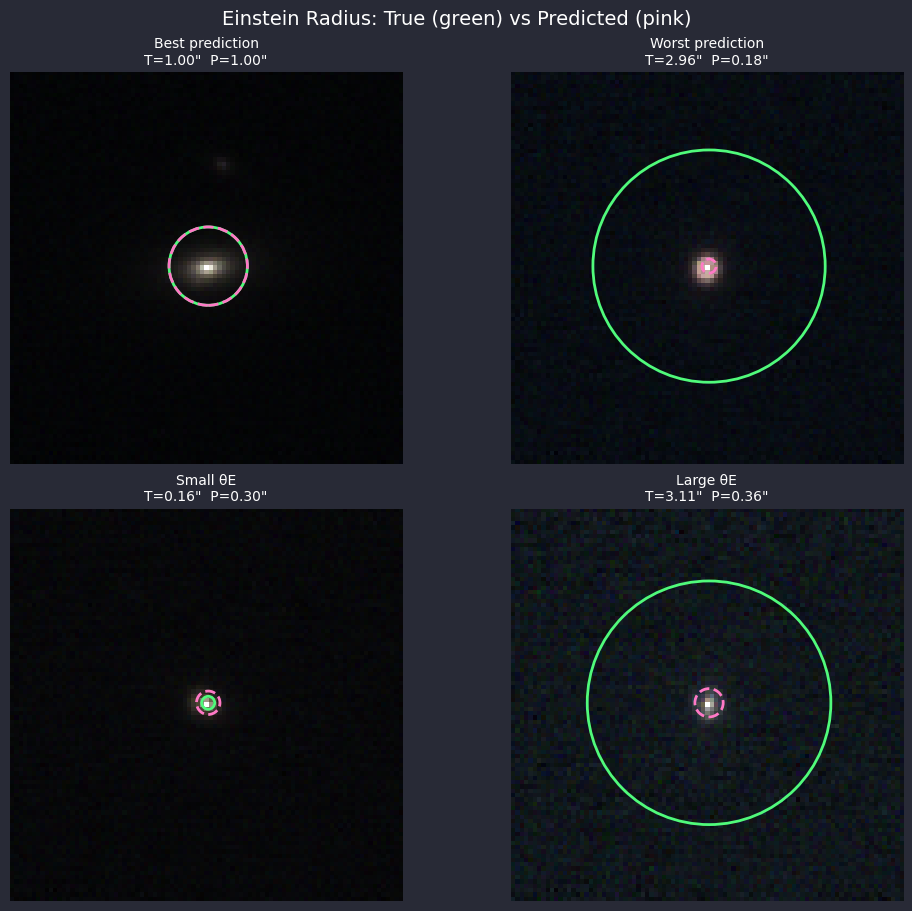

In [33]:
# ==========================================================
# Select 4 representative examples
# ==========================================================
import numpy as np
import matplotlib.pyplot as plt

errors = np.abs(y_pred - y_true)

idx_best  = np.argmin(errors)
idx_worst = np.argmax(errors)
idx_small = np.argmin(y_true)
idx_large = np.argmax(y_true)

indices = [idx_best, idx_worst, idx_small, idx_large]
titles  = ["Best prediction",
           "Worst prediction",
           "Small θE",
           "Large θE"]

pixel_scale = 0.11  # arcsec/pixel

plt.style.use('dark_background')
plt.rcParams.update({
    "figure.facecolor": "#282a36",
    "axes.facecolor": "#282a36",
})

fig, axes = plt.subplots(2, 2, figsize=(10, 9), constrained_layout=True)
axes = axes.ravel()

# --- we need to extract images from test_loader again ---
all_images = []
with torch.no_grad():
    for xb, yb in test_loader:
        all_images.append(xb.cpu().numpy())
        
X_test_all = np.concatenate(all_images)  # shape: (N, C, H, W)
X_test_all = np.transpose(X_test_all, (0,2,3,1))  # (N,H,W,C)

for ax, idx, title in zip(axes, indices, titles):

    img = X_test_all[idx]
    true_theta = y_true[idx]
    pred_theta = y_pred[idx]
    
    ax.imshow(img, origin='lower')

    H, W, _ = img.shape
    center = (W/2, H/2)

    r_true = true_theta / pixel_scale
    r_pred = pred_theta / pixel_scale

    circle_true = plt.Circle(center, r_true,
                             color="#50fa7b",
                             fill=False,
                             linewidth=2)

    circle_pred = plt.Circle(center, r_pred,
                             color="#ff79c6",
                             linestyle="--",
                             fill=False,
                             linewidth=2)

    ax.add_patch(circle_true)
    ax.add_patch(circle_pred)

    ax.set_title(f"{title}\nT={true_theta:.2f}\"  P={pred_theta:.2f}\"",
                 fontsize=10)
    ax.axis("off")

plt.suptitle("Einstein Radius: True (green) vs Predicted (pink)", fontsize=14)
plt.show()

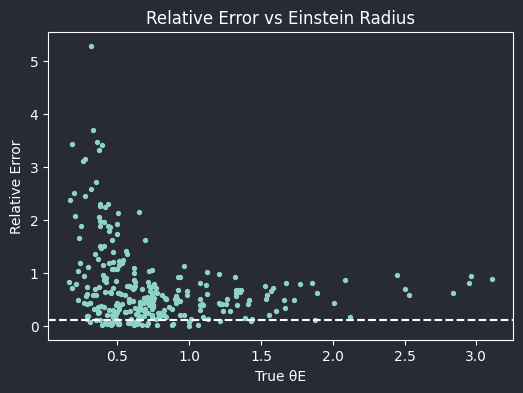

In [34]:
plt.figure(figsize=(6,4))
plt.scatter(y_true, errors / y_true, s=8)
plt.xlabel("True θE")
plt.ylabel("Relative Error")
plt.title("Relative Error vs Einstein Radius")
plt.axhline(0.1, linestyle="--")  # 10% reference
plt.show()

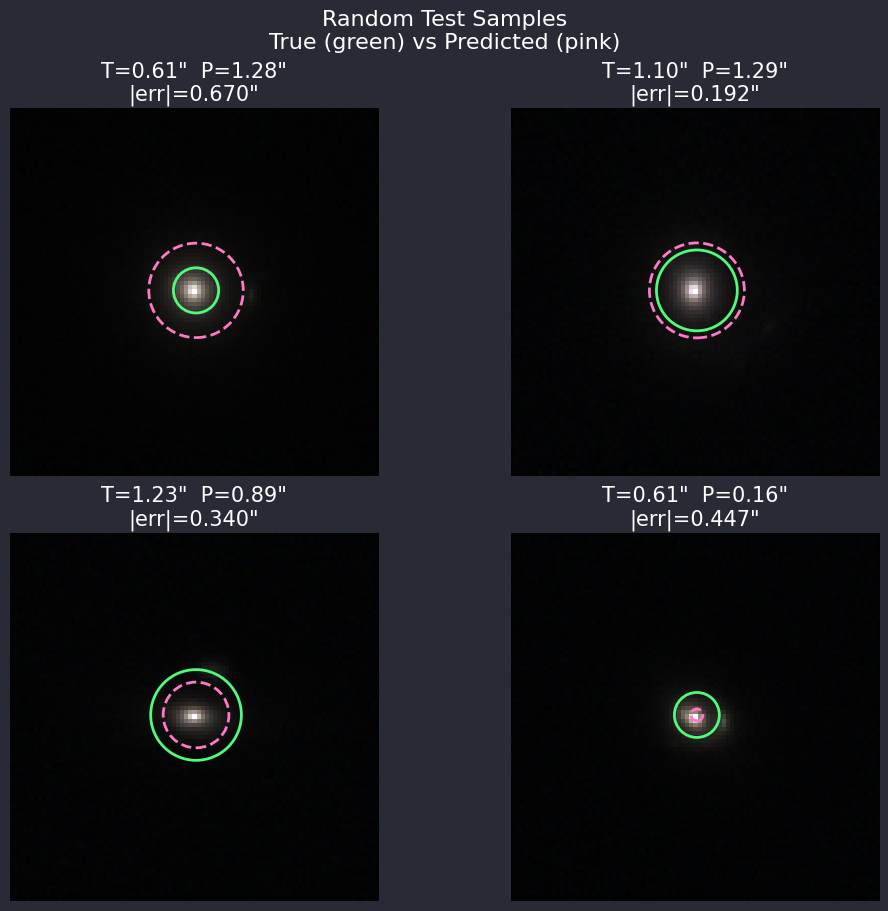

In [62]:
# ==========================================================
# 4 Random Test Samples - Visual Overlay
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import random
import torch

pixel_scale = 0.11  # arcsec per pixel

# ---- Extract all test images (only once) ----
all_images = []
with torch.no_grad():
    for xb, yb in test_loader:
        all_images.append(xb.cpu().numpy())

X_test_all = np.concatenate(all_images)  # (N, C, H, W)
X_test_all = np.transpose(X_test_all, (0,2,3,1))  # (N, H, W, C)

# ---- Select 4 random indices ----
n_show = 4
indices = random.sample(range(len(X_test_all)), n_show)

# ---- Dracula style ----
plt.style.use('dark_background')
plt.rcParams.update({
    "figure.facecolor": "#282a36",
    "axes.facecolor": "#282a36",
    "axes.edgecolor": "#f8f8f2",
    "axes.labelcolor": "#f8f8f2",
    "xtick.color": "#f8f8f2",
    "ytick.color": "#f8f8f2",
})

fig, axes = plt.subplots(2, 2, figsize=(10, 9), constrained_layout=True)
axes = axes.ravel()

for ax, idx in zip(axes, indices):

    img = X_test_all[idx]
    true_theta = y_true[idx]
    pred_theta = y_pred[idx]
    
    ax.imshow(img, origin='lower')

    H, W, _ = img.shape
    center = (W/2, H/2)

    r_true = true_theta / pixel_scale
    r_pred = pred_theta / pixel_scale

    circle_true = plt.Circle(center, r_true,
                             color="#50fa7b",
                             fill=False,
                             linewidth=2)

    circle_pred = plt.Circle(center, r_pred,
                             color="#ff79c6",
                             linestyle="--",
                             fill=False,
                             linewidth=2)

    ax.add_patch(circle_true)
    ax.add_patch(circle_pred)

    error = abs(pred_theta - true_theta)

    ax.set_title(f'T={true_theta:.2f}"  P={pred_theta:.2f}"\n|err|={error:.3f}"',
                 fontsize=15)

    ax.axis("off")

plt.suptitle("Random Test Samples\nTrue (green) vs Predicted (pink)", fontsize=16)
plt.show()

In [64]:
#save model
torch.save(model_cnn.state_dict(), "model.pth")
